## Import Libraries

In [471]:
import pandas as pd
import matplotlib.pyplot as plt

## Read and Explore a CSV File

In [472]:
df = pd.read_csv('../data/raw/jobs_snapshot_27-05-2026.csv')

In [473]:
df.head(1)

,title,location,longitude,latitude,id,redirect_url,adref,__CLASS__,category,description,created,company,salary_is_predicted,contract_time,contract_type,salary_max,salary_min
0,Service & Application Owner (m/w/d) Data Wareh...,"{'display_name': 'Bad Vilbel, Wetteraukreis', ...",8.73553,50.17809,5728119107,https://www.adzuna.de/land/ad/5728119107?se=0A...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTcyODExOTEwNyIsI...,Adzuna::API::Response::Job,"{'tag': 'it-jobs', 'label': 'IT-Stellen', '__C...",Die BHS Bad Homburger Servicegesellschaft mbH ...,2026-05-13T17:14:05Z,{'__CLASS__': 'Adzuna::API::Response::Company'...,0,NaN,NaN,NaN,NaN


Non-numeric json objects correspond to dictionary in Python. They were converted into strings after loading. For further analysis, to extract information from key-value pairs, they should be converted back to dictionaries.

In [474]:
df.columns

Index(['title', 'location', 'longitude', 'latitude', 'id', 'redirect_url',
       'adref', '__CLASS__', 'category', 'description', 'created', 'company',
       'salary_is_predicted', 'contract_time', 'contract_type', 'salary_max',
       'salary_min'],
      dtype='str')

In [475]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4230 entries, 0 to 4229
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                4230 non-null   str    
 1   location             4230 non-null   str    
 2   longitude            3411 non-null   float64
 3   latitude             3411 non-null   float64
 4   id                   4230 non-null   int64  
 5   redirect_url         4230 non-null   str    
 6   adref                4230 non-null   str    
 7   __CLASS__            4230 non-null   str    
 8   category             4230 non-null   str    
 9   description          4230 non-null   str    
 10  created              4230 non-null   str    
 11  company              4230 non-null   str    
 12  salary_is_predicted  4230 non-null   int64  
 13  contract_time        2257 non-null   str    
 14  contract_type        519 non-null    str    
 15  salary_max           177 non-null    float64
 16 

This data is quite complete. All fields relevant to the analysis, apart from those containing salary data, are nor empty.

Non-numeric fiels are of type 'str'.

Numeric field are of types 'int' and 'float64'.

In [476]:
df['description'].iloc[0]

'Die BHS Bad Homburger Servicegesellschaft mbH – Teil der Deutschen Leasing Gruppe – verantwortet zentrale Service- und Unterstützungsleistungen für die Unternehmensbereiche. Im IT-Betrieb sorgen wir für die zuverlässige, sichere und zukunftsorientierte Bereitstellung unserer Anwendungen und Datenplattformen. Unsere Arbeitsweise wird immer agiler: transparent, iterativ und eng verzahnt mit Fachbereichen, Entwicklungsteams und externen Partnern. Zur Verstärkung unseres Teams am Standort Bad Vilbe…'

The description of each job post is being loaded in a limitied version - with 500 characters at the begining of the text. This is the limit set by API. There is no possibilities to obtain such information from the description as: the requirements to language levels and tech skills. Therefore, the further research will be focused on analysing job titles, salary, companies, and location - data that can be received from other fields.

## Key Metrics

In [477]:
print(f'Total amount of job posts found: {len(df)}')

Total amount of job posts found: 4230


The data downloaded from API contains all jobs with the word 'data' in their title and description. 

In [478]:
print(f'Number of unique job titles: {df['title'].nunique()}')

Number of unique job titles: 2480


In [479]:
df.title.unique()[:100]

<StringArray>
[                                                     'Service & Application Owner (m/w/d) Data Warehouse / Data Platform',
                                                                                         'Praktikum Panel Data Management',
                                                                    'Praktikum Personal - Data Management & Authorization',
                                                               'Product Manager - Data Governance & Analytics Engineering',
                                                                                         '(Senior) Data Scientist - m/f/d',
                                                                'Duales Studium Wirtschaftsinformatik - Data Science 2027',
                                                                                    'Head of Data Science - Generative AI',
                                                                                    'Projektleiter:in (m/w/d) Data Cen

The data includes different data positions, such as Data Engineer, Data Architect, Data Migration Developer, as well as non-data positions, such as Legal Counsel Data Privacy. In our research, we will be only focusing on Data Anlyst positions.

#### Companies

In [480]:
df['company'].notna().sum()

np.int64(4230)

In [481]:
type(df["company"].iloc[0])

str

In [482]:
df["company"].iloc[0]

"{'__CLASS__': 'Adzuna::API::Response::Company', 'display_name': 'BHS Bad Homburger Servicegesellschaft mbH'}"

The field 'company' has type 'str' and looks like a dictionary. To extract a company's name, it is necessary to convert a string into dictionary and take the value of the key 'display_name'.

In [483]:
import ast  # Abstract Syntax Trees

df['company_dict'] = df['company'].apply(ast.literal_eval) #convert str to dict
df['company_name'] = df['company_dict'].apply(lambda x: x.get('display_name'))  #take the company name
df['company_name'].iloc[0]

'BHS Bad Homburger Servicegesellschaft mbH'

ast is a Python library. 
ast.literal_eval is a function that parses text literarly, according to Python syntax. If it identifies curly brackets { }, is converts the text into a dictionary. If it identifies square brackets [ ], it converts the text into a list.

#### Location

In [484]:
type(df['location'].iloc[0])

str

In [485]:
df['location'].iloc[5]

"{'area': ['Deutschland', 'Baden-Württemberg', 'Heilbronn (Kreis)', 'Neckarsulm'], 'display_name': 'Neckarsulm, Heilbronn (Kreis)', '__CLASS__': 'Adzuna::API::Response::Location'}"

The 'location' field is of type 'str' and should be converted into a dictionary.

In [486]:
df['location'] = df['location'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else {})

#take the value of the key 'display_name'
df['location_name'] = df['location'].apply(lambda x: x.get('display_name'))
df['location_name'].iloc[0]

'Bad Vilbel, Wetteraukreis'

In [487]:
#split location_name to get city as a first part before comma, then delete spaces
df['city'] = df['location_name'].str.split(',').str[0].str.strip()

#### Filtering Data Analyst vacancies

For filtering, we use several key words and phrases in English and German:
- data analyst,
- daten analyst,
- datenanalyst.

In [488]:
#only data analyst
data_analyst_jobs = df[df['title'].str.contains('data analyst|daten analyst|datenanalyst', case=False, na=False)]
# filter out education
data_analyst_jobs = data_analyst_jobs[~data_analyst_jobs['title'].str.contains('weiterbildung|bildungsgutschein', case=False, na=False)]

print(f'Data Analyst positions: {len(data_analyst_jobs)}')

Data Analyst positions: 239


#### The distribution of vacancies by seniority

Key words and phrases for junior positions: juior, entry level, trainee, etc.

In [489]:
junior_data_analyst_jobs = data_analyst_jobs[data_analyst_jobs['title'].str.contains('junior|entry level|trainee|praktikant|graduate|einsteiger', case=False)]
print(f'Junior data analyst positions: {len(junior_data_analyst_jobs)}')

Junior data analyst positions: 10


Key words and phrases for senior positions: senior, lead, leiter, expert, etc.

In [490]:
senior_data_analyst_jobs = data_analyst_jobs[data_analyst_jobs['title'].str.contains('senior|lead|principal|head|manager|director|leiter|leitung|teamleiter|projektleiter|expert', case=False)]
print(f'Senior data anlyst positions: {len(senior_data_analyst_jobs)}')

Senior data anlyst positions: 62


In [491]:
middle_data_analyst_jobs = data_analyst_jobs[
    ~data_analyst_jobs.index.isin(senior_data_analyst_jobs.index)
    & ~data_analyst_jobs.index.isin(junior_data_analyst_jobs.index)
]
print(f'Middle or undefined data analyst positions: {len(middle_data_analyst_jobs)}')

Middle or undefined data analyst positions: 167


Out of 239 Data Analyst vacancies:
- 10, or 4% are junior positions, 
- 62, or 26% are senior and management positions,
- 167, or 70% are middle or undefined postions.

#### The availability of information about salary

In [492]:
#prepare salary columns for quantitative analysis

data_analyst_jobs['salary_max'].notnull().sum()

np.int64(21)

In [493]:
data_analyst_jobs["salary_min"].notnull().sum()

np.int64(21)

In [494]:
jobs_with_salary = data_analyst_jobs[data_analyst_jobs["salary_min"].notnull() | data_analyst_jobs["salary_max"].notnull()]
print(f'Only {len(jobs_with_salary)} out of {len(data_analyst_jobs)} job vacancies have salary information.')

Only 21 out of 239 job vacancies have salary information.


Few job postings have information about minimum and maximum salary, which indicates a lack of transparancy from employers and recruiting companies on this point.

#### Identifying a salary range for Data Analyst vacancies

In [495]:
#Preview of salary columns
salary_min = data_analyst_jobs['salary_min'].min()
print(data_analyst_jobs.sort_values('salary_min').head(5)[['title', 'salary_min']])

                                                  title  salary_min
734                                 Senior Data Analyst         2.0
2411           Senior Data Analyst - Operations (m/f/x)        73.0
2030               (Senior) Energy Data Analyst (d/f/m)        80.0
3493  Senior Data Analyst/Business Intelligence Spec...     48000.0
530                                        Data Analyst     50000.0


In [496]:
salary_max = data_analyst_jobs['salary_max'].max()
print(data_analyst_jobs.sort_values('salary_max').head(5)[['title', 'salary_max']])

                                                  title  salary_max
734                                 Senior Data Analyst         4.0
2411           Senior Data Analyst - Operations (m/f/x)        84.0
2030               (Senior) Energy Data Analyst (d/f/m)       100.0
3493  Senior Data Analyst/Business Intelligence Spec...     48000.0
530                                        Data Analyst     63000.0


Some records have salary per hour, which can create a misleading result. The annual salary starts with a five-digit number, a condition should be applied that the minimum salary is equal or more than 10000. Thus, a salary per hour is excluded from the analysis.

In [497]:
annual_salary = data_analyst_jobs[(data_analyst_jobs['salary_min'] >= 10000) & (data_analyst_jobs['salary_max'] >= 10000)].copy()

In [498]:
#average salary
annual_salary['salary_avg'] = (annual_salary['salary_min'] + annual_salary['salary_max']) / 2
annual_salary['salary_avg'].describe()

count        18.000000
mean      85107.805556
std       33940.552513
min       48000.000000
25%       62125.000000
50%       72490.250000
75%       96525.000000
max      178100.000000
Name: salary_avg, dtype: float64

In [499]:
annual_salary_min = annual_salary['salary_min'].min()
print(f'The lowest annual salary of Data Analyst positions is: {annual_salary_min}')

The lowest annual salary of Data Analyst positions is: 48000.0


In [500]:
annual_salary_max = annual_salary['salary_max'].max()
print(f'The highest annual salary of Data Analyst positions is : {annual_salary_max}')

The highest annual salary of Data Analyst positions is : 187200.0


The annual salary range for Data Analyst positions is from 42,000 to 187,200 Euro.

In [501]:
salary_avg = annual_salary['salary_avg'].dropna()
salary_avg

500      60000.0
530      56500.0
739     117500.0
1168     70000.0
1572     64000.0
1583     67500.0
1663     77500.0
1710     67500.0
1746    136500.0
1747    178100.0
1784     77500.0
2229     97500.0
2901     74980.5
3225     61500.0
3491     93600.0
3493     48000.0
3609     60000.0
3824    123760.0
Name: salary_avg, dtype: float64

In [502]:
salary_avg.mean()

np.float64(85107.80555555556)

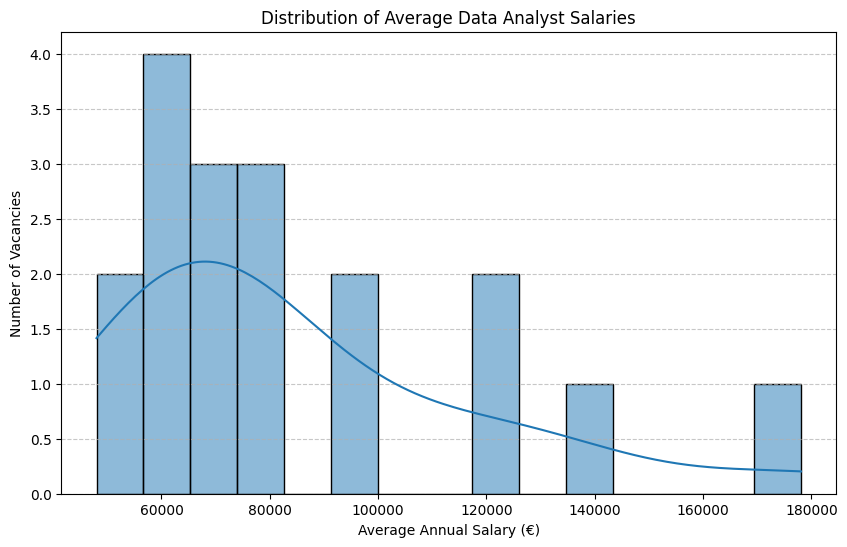

In [503]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    salary_avg,
    bins=15,
    kde=True
)

plt.title('Distribution of Average Data Analyst Salaries')
plt.xlabel('Average Annual Salary (€)')
plt.ylabel('Number of Vacancies')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Creating a DataFrame with key metrics for a dashboard in Power BI

In [504]:
key_metrics = pd.DataFrame([{
    'Total Jobs': len(df), 
    'Data Analyst Jobs': len(data_analyst_jobs),
    'Junior Data Analyst Jobs': len(junior_data_analyst_jobs),
    'Middle Data Analyst Jobs': len(middle_data_analyst_jobs),
    'Senior Data Analyst Jobs': len(senior_data_analyst_jobs),
    'Jobs with Salary Information': len(jobs_with_salary),
    'Lowest Annual Salary': int(annual_salary_min),
    'Highest Annual Salary': int(annual_salary_max),
    'Average Salary': int(salary_avg.mean())
}])

key_metrics.to_csv('../data/raw/dashboard/key_metrics.csv', index=False)


#### Top companies

In [505]:
top_companies = data_analyst_jobs['company_name'].value_counts().head(5).reset_index()
top_companies.columns = ['company_name', 'job_postings']
print(f'Top 5 companies with the most Data Analystjob postings: {top_companies}')

Top 5 companies with the most Data Analystjob postings:                   company_name  job_postings
0           KIND GmbH & Co. KG            15
1             Redcare Pharmacy             7
2                        Serco             7
3  ISR Information Products AG             5
4               EY Deutschland             4


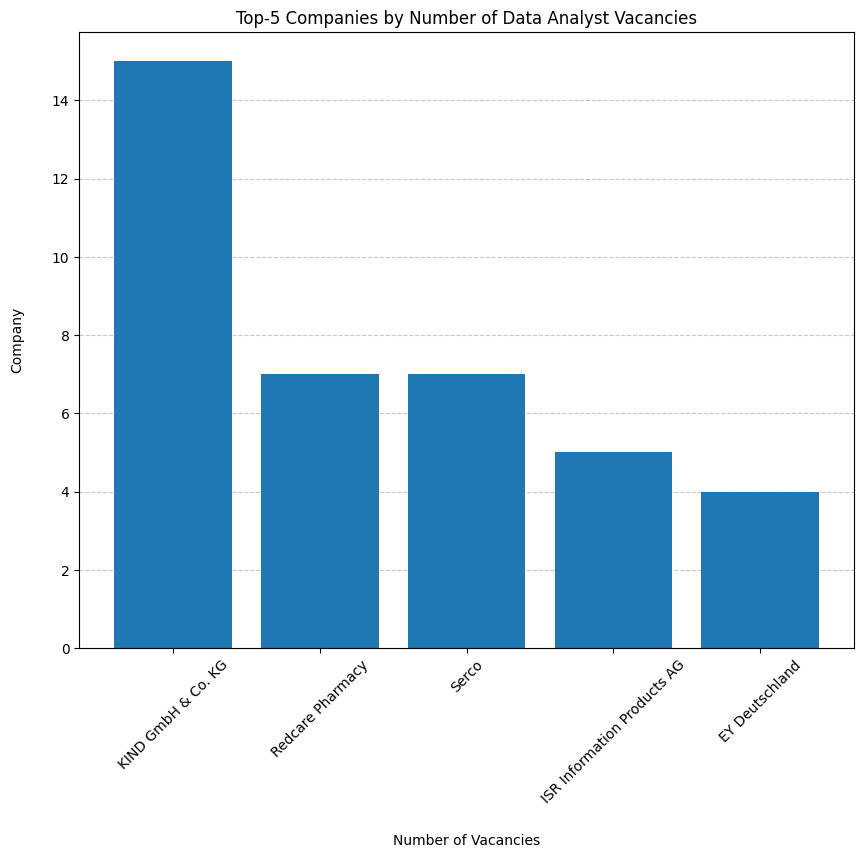

In [506]:
companies = top_companies['company_name']
counts = top_companies['job_postings']

plt.figure(figsize=(10, 8))
plt.bar(companies, counts)  #top-5 companies with the most jobs postings

plt.title('Top-5 Companies by Number of Data Analyst Vacancies')
plt.xlabel('Number of Vacancies', labelpad=20)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.ylabel('Company', labelpad=20)

plt.show()

4 of 5 top-5 companies provide IT services and products. One is a recruitment agency working in German, Austrian and Swiss job market.

In [507]:
# save to csv for Power BI dashboard
top_companies.to_csv('../data/raw/dashboard/top_companies.csv', index=False)

#### Top cities

In [508]:
top_cities = data_analyst_jobs['city'].value_counts().head(6)
print(f'Top 6 cities by number of vacancies: {top_cities}')

Top 6 cities by number of vacancies: city
Deutschland          36
Berlin               23
Köln                 10
Frankfurt am Main     8
Mitte                 8
Altstadt-Lehel        7
Name: count, dtype: int64


In [509]:
#exclude Deutschland from the top cities
data_analyst_jobs_clean = data_analyst_jobs[data_analyst_jobs['city'] != 'Deutschland']

top_cities = data_analyst_jobs_clean['city'].value_counts().head(5).reset_index()
print(f'Top 5 cities by number of vacancies: {top_cities}')

Top 5 cities by number of vacancies:                 city  count
0             Berlin     23
1               Köln     10
2  Frankfurt am Main      8
3              Mitte      8
4     Altstadt-Lehel      7


In [510]:
top_cities.columns = ['city', 'job_postings']

<Figure size 1000x600 with 0 Axes>

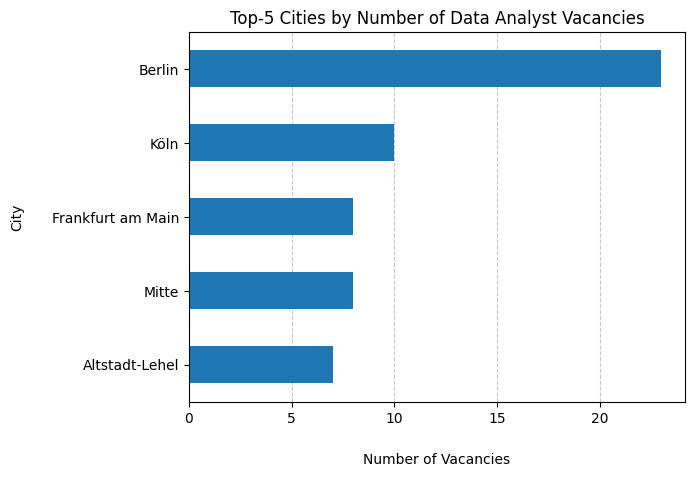

In [511]:
plt.figure(figsize=(10, 6))
top_cities.sort_values(by='job_postings').plot(
    x='city',
    y='job_postings',
    kind='barh',
    legend=False
)  #with the city with the most jobs postings at the top

plt.title('Top-5 Cities by Number of Data Analyst Vacancies')
plt.xlabel('Number of Vacancies', labelpad=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.ylabel('City', labelpad=20)

plt.show()

In [512]:
#save to csv for Power BI dashboard
top_cities.to_csv('../data/raw/dashboard/top_cities.csv', index=False)

## Analysis, Identification of Relationships, and Visualisation

#### Junior Data Analyst roles

In [513]:
junior_salary_min = junior_data_analyst_jobs['salary_min'].min()
print(f'The lowest annual salary of junior Data Analyst positions is: {junior_salary_min}')

The lowest annual salary of junior Data Analyst positions is: nan


In [514]:
junior_salary_max = junior_data_analyst_jobs['salary_max'].max()
print(f'The highest annual salary of junior Data Analyst positions is: {junior_salary_max}')

The highest annual salary of junior Data Analyst positions is: nan


The salary information for junior Data Analyst positions is unavailable.

In [515]:
senior_data_analyst_jobs['company_name'].value_counts().head(5)

company_name
ISR Information Products AG    5
ABOUT YOU SE & Co. KG          3
exmox                          3
getolo GmbH                    2
Jobgether                      2
Name: count, dtype: int64

#### Average salary by city

In [523]:
avg_salary_by_city = (
    annual_salary[annual_salary['city'] != 'Deutschland']
    .groupby('city')['salary_avg']
    .agg(['mean', 'count'])
    .reset_index()
)

top_5_cities = avg_salary_by_city.sort_values('mean', ascending=False).head(5)
top_5_cities

,city,mean,count
8,Kirdorf,157300.0,2
2,Berlin,117500.0,1
9,Maxvorstadt,97500.0,1
5,Eppinghofen,77500.0,2
1,Altstadt-Lehel,74980.5,1


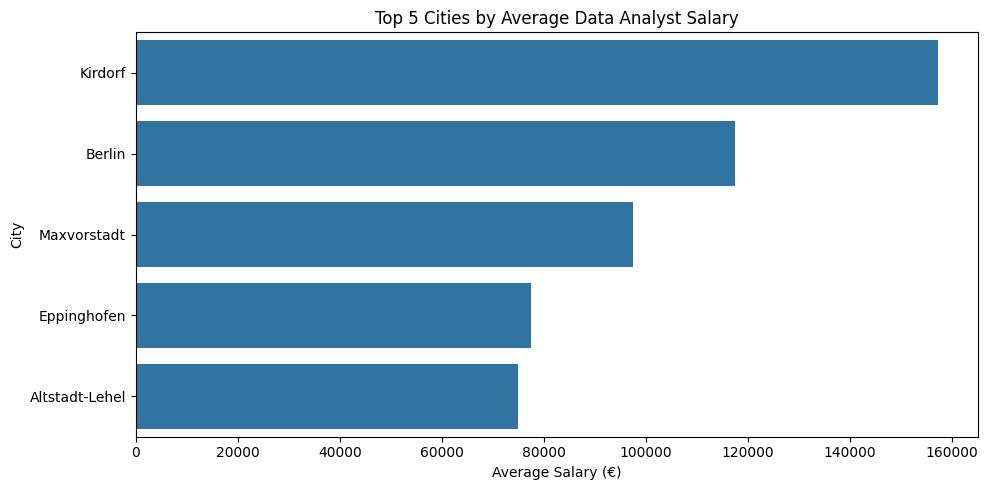

In [524]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_5_cities,
    x='mean',
    y='city'
)

plt.xlabel('Average Salary (€)')
plt.ylabel('City')
plt.title('Top 5 Cities by Average Data Analyst Salary')

plt.tight_layout()
plt.show()

#### Average salary by companies

In [525]:
avg_salary_by_company = (
    annual_salary
    .groupby('company_name')['salary_avg']
    .agg(['mean', 'count'])
    .reset_index()
)

top_5_companies = avg_salary_by_company.sort_values('mean', ascending=False).head(5)
top_5_companies

,company_name,mean,count
5,N Consulting Ltd,157300.0,2
1,Coating Concepts,123760.0,1
7,Quince,117500.0,1
3,Flexa,97500.0,1
11,grey engineering,77500.0,1


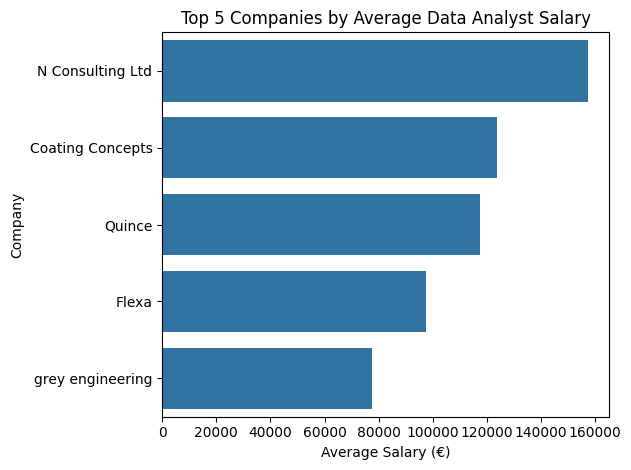

In [527]:
sns.barplot(
    data=top_5_companies,
    x='mean',
    y='company_name'
)

plt.xlabel('Average Salary (€)')
plt.ylabel('Company')
plt.title('Top 5 Companies by Average Data Analyst Salary')

plt.tight_layout()
plt.show()